In [2]:
import os
import pickle
import warnings

import torch
import torchvision.transforms as transforms
from torchvision.io import read_image

warnings.filterwarnings('ignore')

In [19]:
nerv_save_dir = '../plotting_source_data/NeRV/C-INRs_perhaps_care_about_objects'
mlp_save_dir = '../plotting_source_data/MLP/C-INRs_perhaps_care_about_objects'

nerv_per_vid_patch_deltas_var_dict = pickle.load(open(f'{nerv_save_dir}/per_vid_patch_deltas_var_dict.pkl', 'rb'))
mlp_per_vid_patch_deltas_var_dict = pickle.load(open(f'{mlp_save_dir}/per_vid_patch_deltas_var_dict.pkl', 'rb'))

In [12]:
rgb_img_paths = {
    "0005": "../data/cityscapes_vps/val/img_all/frankfurt_000000_001736_leftImg8bit.png",
    "0175": "../data/cityscapes_vps/val/img_all/frankfurt_000001_049683_leftImg8bit.png",
    "12_n-ytHkMceew": "../data/VIPSeg-Dataset/VIPSeg/VIPSeg_720P/images/12_n-ytHkMceew/00002537.jpg",
    "26_cblDl5vCZnw": "../data/VIPSeg-Dataset/VIPSeg/VIPSeg_720P/images/26_cblDl5vCZnw/00000976.jpg"
}

vipseg_vids = ["12_n-ytHkMceew", "26_cblDl5vCZnw"]

In [50]:
import matplotlib.pyplot as plt
import numpy as np

def per_video_plot_box_and_whiskers(axs, nerv_patch_deltas_var_dict, mlp_patch_deltas_var_dict, colors):

    # Define dictionaries and keys
    dicts = [mlp_patch_deltas_var_dict, mlp_patch_deltas_var_dict, mlp_patch_deltas_var_dict, nerv_patch_deltas_var_dict, nerv_patch_deltas_var_dict, ]
    keys = ["layer_3", "layer_2", "layer_1", "head", "blk_3", ]

    for i, (key, data_dict) in enumerate(zip(keys, dicts)):
        sorted_deltas_dict = data_dict["sorted_deltas_dict"]
        tensor_dict = sorted_deltas_dict[key]
        
        instances_deltas = tensor_dict["instances_deltas"][~torch.isnan(tensor_dict["instances_deltas"])]
        rgb_clusters_deltas = tensor_dict["rgb_clusters_deltas"][~torch.isnan(tensor_dict["rgb_clusters_deltas"])]
        gabor_clusters_deltas = tensor_dict["gabor_clusters_deltas"][~torch.isnan(tensor_dict["gabor_clusters_deltas"])]
        gridcells_deltas = tensor_dict["gridcells_deltas"][~torch.isnan(tensor_dict["gridcells_deltas"])]

        tensor_logs = [np.log(np.sqrt(instances_deltas)),
                       np.log(np.sqrt(rgb_clusters_deltas)),
                       np.log(np.sqrt(gabor_clusters_deltas)),
                       np.log(np.sqrt(gridcells_deltas))]

        # Plot box plots for each tensor in the current layer
        box = axs[i].boxplot(
            tensor_logs, positions=[1, 2, 3, 4], patch_artist=True, 
            medianprops=dict(color="black", alpha=0.7),
            flierprops=dict(markeredgecolor='black', marker='o', markersize=4, linestyle='none', alpha=0.4))

        # Customize box colors
        for box_part, color in zip(box['boxes'], colors):
            box_part.set_facecolor(color)

        # turn off x and y ticks
        axs[i].set_xticks([]) # axs[i].set_xticks([1, 2, 3, 4])
        axs[i].set_yticks([])
        axs[i].set_xticklabels([])
        axs[i].set_yticklabels([])

    legend_labels = ['Instances', 'RGB Clusters', 'Gabor Clusters', 'Gridcells']
    legend_handles = [plt.Line2D([0], [0], marker='s', color='w', markerfacecolor=color, markersize=10) for color in colors]

    return axs, (legend_labels, legend_handles)


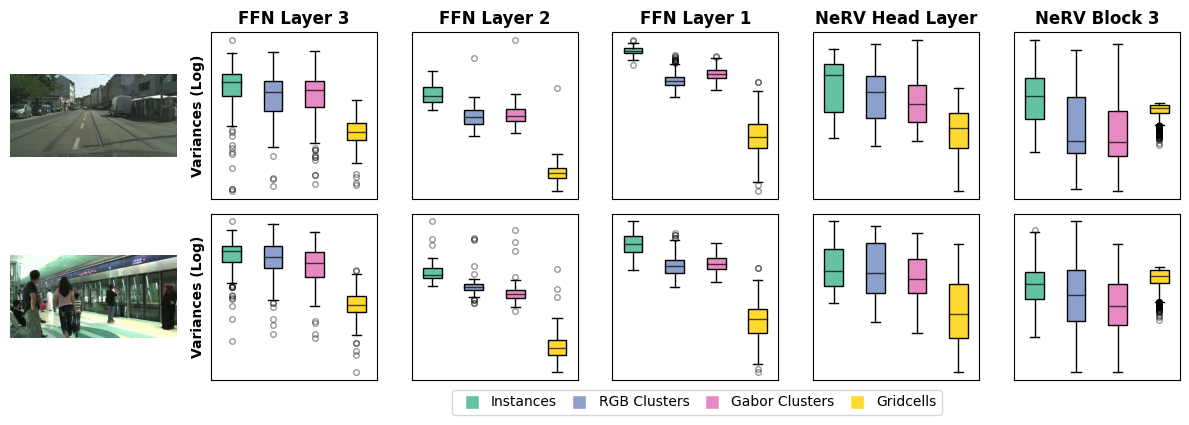

In [51]:
vidnames = ["0005", "26_cblDl5vCZnw"]
colors = plt.cm.get_cmap('Set2').colors
colors = [colors[i] for i in [0,2,3,5]]

# num_vids x 6
fig, axs = plt.subplots(len(vidnames), 6, figsize=(12, 4), tight_layout=True)#, gridspec_kw={'wspace': 0.7}) #  gridspec_kw={'width_ratios': [1, 1, 1, 1, 1, 1]},

for vid_idx, vidname in enumerate(vidnames):
    rgb_img = read_image(rgb_img_paths[vidname])
    if vidname in vipseg_vids:
        rgb_img = transforms.CenterCrop((640, 1280))(rgb_img)
    
    axs[vid_idx][0].imshow(rgb_img.permute(1, 2, 0).numpy())
    axs[vid_idx][0].axis('off')
    
    box_plot_axes = [axs[vid_idx][1], axs[vid_idx][2], axs[vid_idx][3], axs[vid_idx][4], axs[vid_idx][5]]
    
    populated_axs, (legend_labels, legend_handles) =\
        per_video_plot_box_and_whiskers(box_plot_axes, nerv_per_vid_patch_deltas_var_dict[vidname], mlp_per_vid_patch_deltas_var_dict[vidname], colors)
        
    axs[vid_idx][1], axs[vid_idx][2], axs[vid_idx][3], axs[vid_idx][4], axs[vid_idx][5] = populated_axs
    
axs[0][1].set_ylabel('Variances (Log)', fontsize=10, fontweight='bold') # Deviation from Actual Contribution (Log)
axs[1][1].set_ylabel('Variances (Log)', fontsize=10, fontweight='bold') # Deviation from Actual Contribution (Log)

axs[0][1].set_title('FFN Layer 3', fontsize=12, fontweight='bold')
axs[0][2].set_title('FFN Layer 2', fontsize=12, fontweight='bold')
axs[0][3].set_title('FFN Layer 1', fontsize=12, fontweight='bold')
axs[0][4].set_title('NeRV Head Layer', fontsize=12, fontweight='bold')
axs[0][5].set_title('NeRV Block 3', fontsize=12, fontweight='bold')


plt.subplots_adjust(wspace=0.2)

fig.legend(legend_handles, legend_labels, loc='upper center', ncol=4, bbox_to_anchor=(0.585, 0.03), columnspacing=0.6, handletextpad=0.4)


## Save Figure

In [49]:
os.makedirs('outputs/C/', exist_ok=True)
fig.savefig('outputs/C/4.4-variance_of_patch_deltas.pdf', bbox_inches="tight", pad_inches=0.02)